# Experiment: ESS and MESS Uniform with Varying M

This notebook compares ESS (MESS with M=1) and MESS uniform for varying number of proposals M = [2, 5, 10, 50, 100, 500, 1000] on a GP regression problem with D=5 dimensions. We track the number of intervals (shrinking steps) as a function of M.

In [1]:
import sys
import os
import time

# Get absolute path to src directory (go up from notebooks to repo root)
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
src_path = os.path.join(repo_root, 'src')
sys.path.insert(0, src_path)

print(f"Repo root: {repo_root}")
print(f"Added to path: {src_path}")

import numpy as np
import matplotlib.pyplot as plt
from mess.data.gp_regression import generate_gp_regression_data
from mess.problems.gp_regression import GaussianProcessRegression
from mess.algorithms.ess import ess_step
from mess.algorithms.mess import mess_step


Repo root: /Users/guillers/Documents/GitHub/mess
Added to path: /Users/guillers/Documents/GitHub/mess/src


## Experiment Setup

In [3]:
# Problem parameters
D = 5  # Dimension
num_data = 200
length_scale = 1.0
noise_variance = 0.09

# Sampler parameters
n_iters = 1000  # Number of MCMC iterations
burn_in = 100
seed = 42

# MESS M values to test
M_values = [1, 2, 5, 10, 25, 50, 75, 100, 500, 1000]
M_values = [1, 10, 20]

print(f"Experiment setup:")
print(f"  D = {D}")
print(f"  num_data = {num_data}")
print(f"  n_iters = {n_iters}")
print(f"  M values: {M_values}")


Experiment setup:
  D = 5
  num_data = 200
  n_iters = 1000
  M values: [1, 10, 20]


## Generate GP Regression Data

In [4]:
data = generate_gp_regression_data(
    num_data=num_data,
    num_dims=D,
    length_scale=length_scale,
    noise_variance=noise_variance,
    seed=seed,
)

X = data["X"]
y = data["y"]
x0 = data["f_init"]

print(f"Data shapes:")
print(f"  X: {X.shape}")
print(f"  y: {y.shape}")
print(f"  x0: {x0.shape}")

# Create the problem
problem = GaussianProcessRegression(
    X=X,
    y=y,
    length_scale=length_scale,
    noise_variance=noise_variance,
)
print(f"Initial log-likelihood: {problem.log_likelihood(x0):.4f}")


Data shapes:
  X: (5, 200)
  y: (200,)
  x0: (200,)
Initial log-likelihood: -2426.8620


## Run Experiments with Different M Values

For each M value, we run a full MCMC chain and collect statistics on the number of intervals (shrinking steps) performed by the algorithm.


In [5]:
# Store results
results = {
    'M_values': M_values,
    'mean_intervals': [],
    'std_intervals': [],
    'median_intervals': [],
    'chains': {},
    'intervals': {},
    'times': [],
}

# Run experiments for each M value
for M in M_values:
    print(f"\nRunning MESS with M = {M}...")
    
    # Initialize RNG and chain storage
    rng = np.random.default_rng(seed)
    chain = np.zeros((n_iters, num_data))
    intervals = np.zeros(n_iters, dtype=int)
    x = x0.copy()
    
    # Run MCMC
    t0 = time.time()
    for t in range(n_iters):
        x, nr_intervals, _ = mess_step(x, problem, rng, M=M, use_lp=False)
        chain[t] = x
        intervals[t] = nr_intervals
    elapsed = time.time() - t0
    
    # Compute statistics (excluding burn-in)
    intervals_post_burnin = intervals[burn_in:]
    mean_intervals = np.mean(intervals_post_burnin)
    std_intervals = np.std(intervals_post_burnin)
    median_intervals = np.median(intervals_post_burnin)
    
    # Store results
    results['mean_intervals'].append(mean_intervals)
    results['std_intervals'].append(std_intervals)
    results['median_intervals'].append(median_intervals)
    results['chains'][M] = chain
    results['intervals'][M] = intervals
    results['times'].append(elapsed)
    
    print(f"  Mean intervals: {mean_intervals:.4f} ± {std_intervals:.4f}")
    print(f"  Median intervals: {median_intervals:.1f}")
    print(f"  Time: {elapsed:.2f} seconds")

print("\n" + "="*60)
print("Experiment completed!")



Running MESS with M = 1...
  Mean intervals: 6.9967 ± 3.4307
  Median intervals: 7.0
  Time: 0.13 seconds

Running MESS with M = 10...
  Mean intervals: 1.3089 ± 0.7529
  Median intervals: 1.0
  Time: 0.08 seconds

Running MESS with M = 20...
  Mean intervals: 0.8600 ± 0.5680
  Median intervals: 1.0
  Time: 0.09 seconds

Experiment completed!


## Plot Results: Number of Intervals vs M

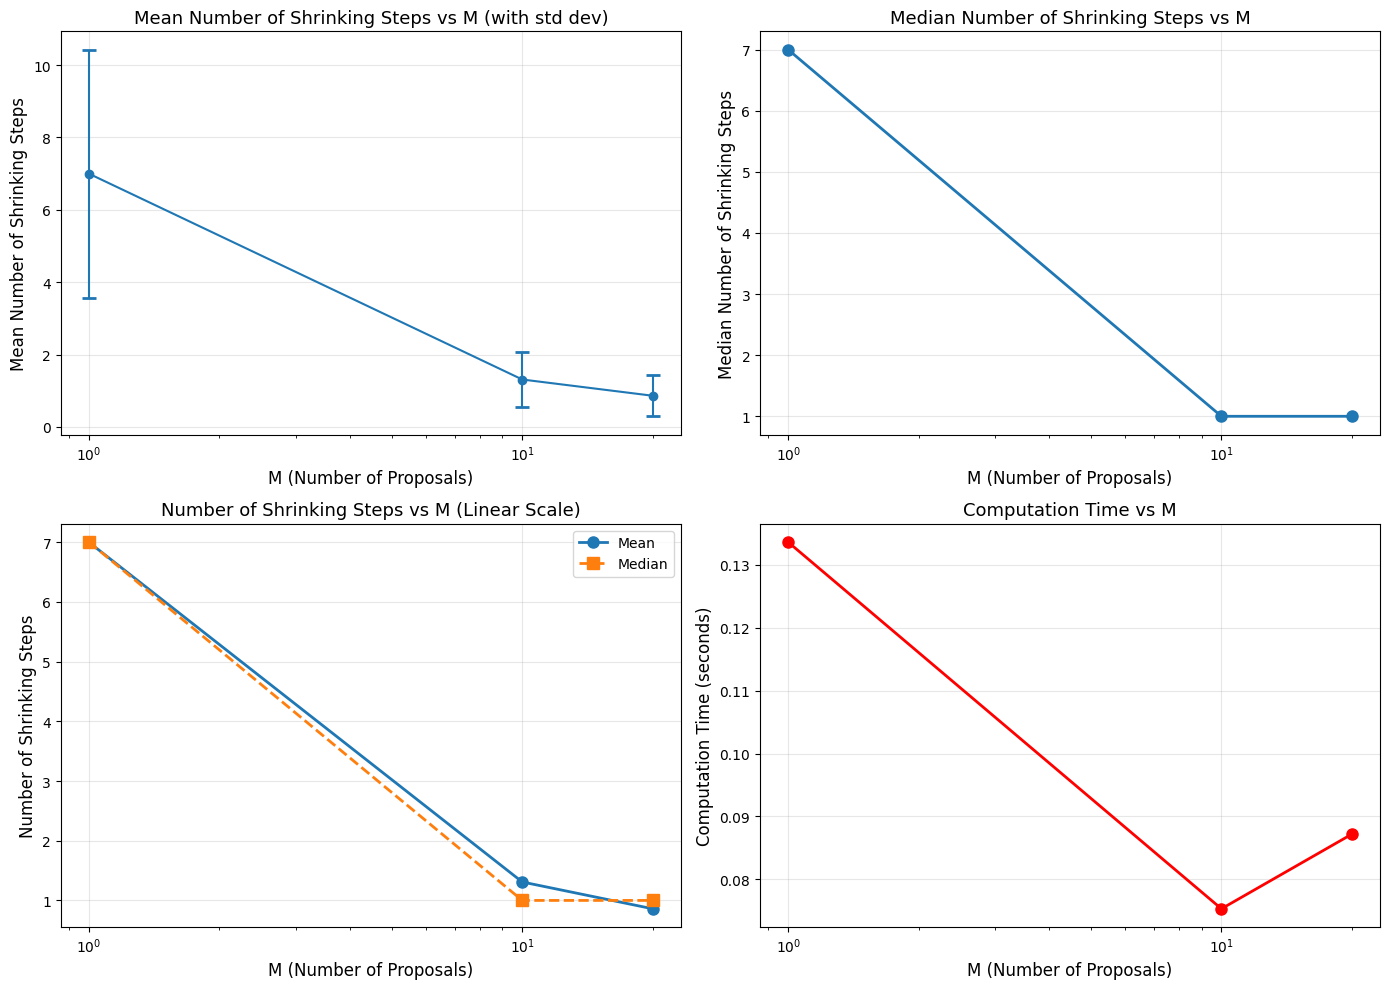


Summary Table:
M          Mean Int.       Std Dev         Median          Time (s)       
1          6.9967          3.4307          7.0             0.1336         
10         1.3089          0.7529          1.0             0.0753         
20         0.8600          0.5680          1.0             0.0872         


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Mean number of intervals with error bars
ax = axes[0, 0]
ax.errorbar(results['M_values'], results['mean_intervals'], 
            yerr=results['std_intervals'], fmt='o-', capsize=5, capthick=2)
ax.set_xlabel('M (Number of Proposals)', fontsize=12)
ax.set_ylabel('Mean Number of Shrinking Steps', fontsize=12)
ax.set_title('Mean Number of Shrinking Steps vs M (with std dev)', fontsize=13)
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

# Plot 2: Median number of intervals
ax = axes[0, 1]
ax.plot(results['M_values'], results['median_intervals'], 'o-', linewidth=2, markersize=8)
ax.set_xlabel('M (Number of Proposals)', fontsize=12)
ax.set_ylabel('Median Number of Shrinking Steps', fontsize=12)
ax.set_title('Median Number of Shrinking Steps vs M', fontsize=13)
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

# Plot 3: Linear scale for comparison
ax = axes[1, 0]
ax.plot(results['M_values'], results['mean_intervals'], 'o-', linewidth=2, markersize=8, label='Mean')
ax.plot(results['M_values'], results['median_intervals'], 's--', linewidth=2, markersize=8, label='Median')
ax.set_xlabel('M (Number of Proposals)', fontsize=12)
ax.set_ylabel('Number of Shrinking Steps', fontsize=12)
ax.set_title('Number of Shrinking Steps vs M (Linear Scale)', fontsize=13)
ax.set_xscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Computation time
ax = axes[1, 1]
ax.plot(results['M_values'], results['times'], 'o-', linewidth=2, markersize=8, color='red')
ax.set_xlabel('M (Number of Proposals)', fontsize=12)
ax.set_ylabel('Computation Time (seconds)', fontsize=12)
ax.set_title('Computation Time vs M', fontsize=13)
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary table
print("\nSummary Table:")
print("="*80)
print(f"{'M':<10} {'Mean Int.':<15} {'Std Dev':<15} {'Median':<15} {'Time (s)':<15}")
print("="*80)
for i, M in enumerate(results['M_values']):
    print(f"{M:<10} {results['mean_intervals'][i]:<15.4f} {results['std_intervals'][i]:<15.4f} {results['median_intervals'][i]:<15.1f} {results['times'][i]:<15.4f}")
print("="*80)


## Trace Plots: Number of Intervals Over Iterations

Visualize how the number of intervals evolves during the MCMC chain for different M values.


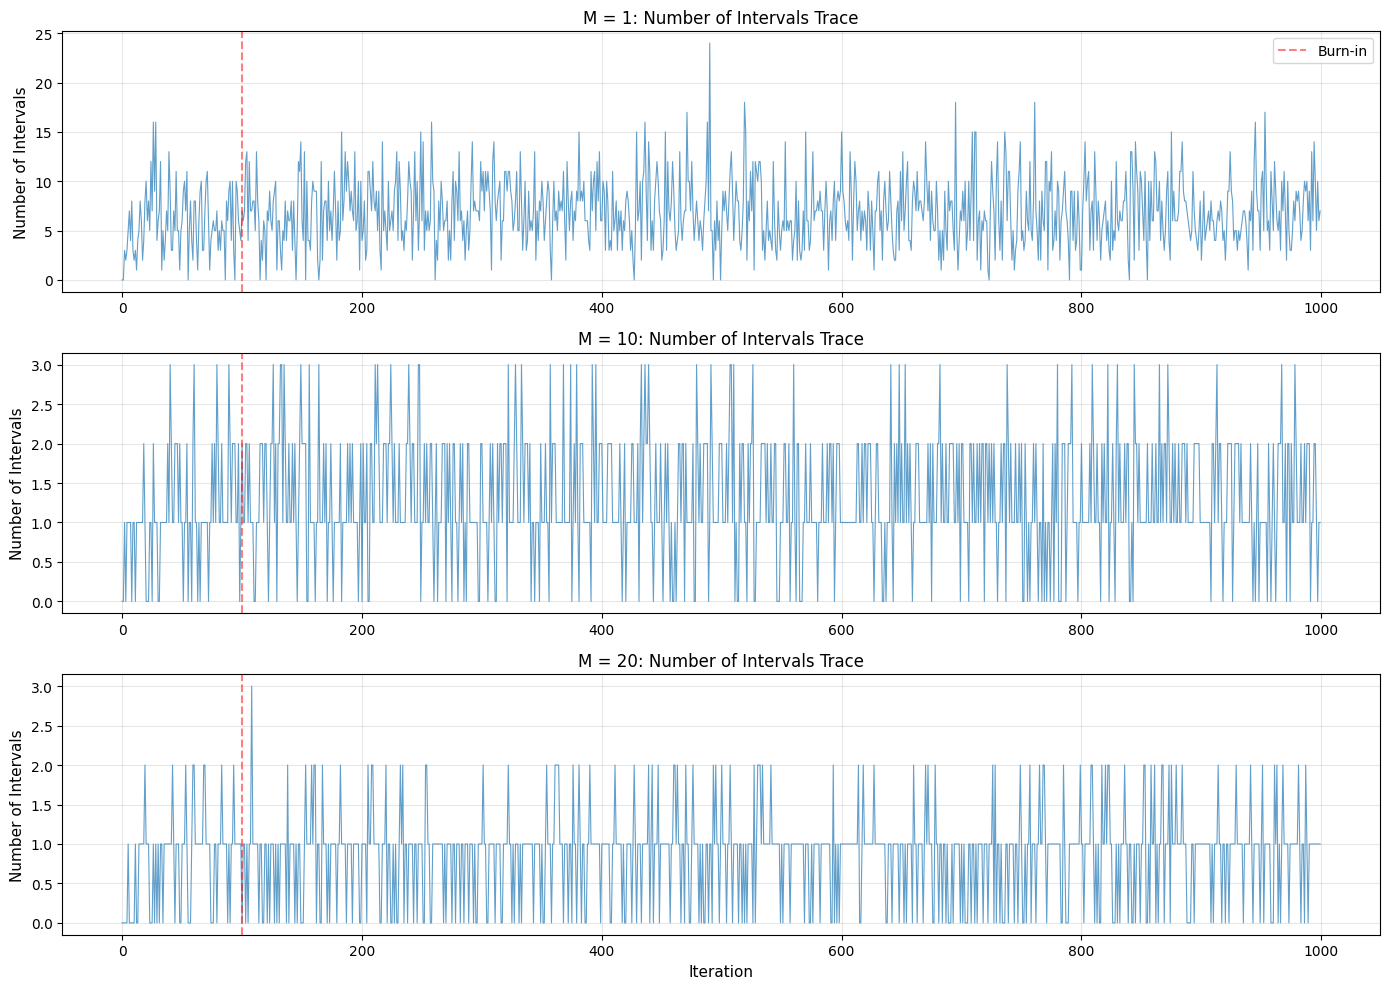

In [8]:
# Select a subset of M values for trace plot visualization
M_subset = [1, 10, 20]

fig, axes = plt.subplots(len(M_subset), 1, figsize=(14, 10))

for idx, M in enumerate(M_subset):
    ax = axes[idx]
    intervals_trace = results['intervals'][M]
    ax.plot(intervals_trace, alpha=0.7, linewidth=0.8)
    ax.axvline(burn_in, color='red', linestyle='--', alpha=0.5, label='Burn-in')
    ax.set_ylabel('Number of Intervals', fontsize=11)
    ax.set_title(f'M = {M}: Number of Intervals Trace', fontsize=12)
    ax.grid(True, alpha=0.3)
    if idx == len(M_subset) - 1:
        ax.set_xlabel('Iteration', fontsize=11)
    if idx == 0:
        ax.legend()

plt.tight_layout()
plt.show()


## Box Plots: Distribution of Intervals for Each M

Compare the distribution of number of intervals across different M values.


/var/folders/jw/64vkfdg1407__zgldz2hpjfr0000gn/T/ipykernel_1655/1275172090.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=labels, patch_artist=True)


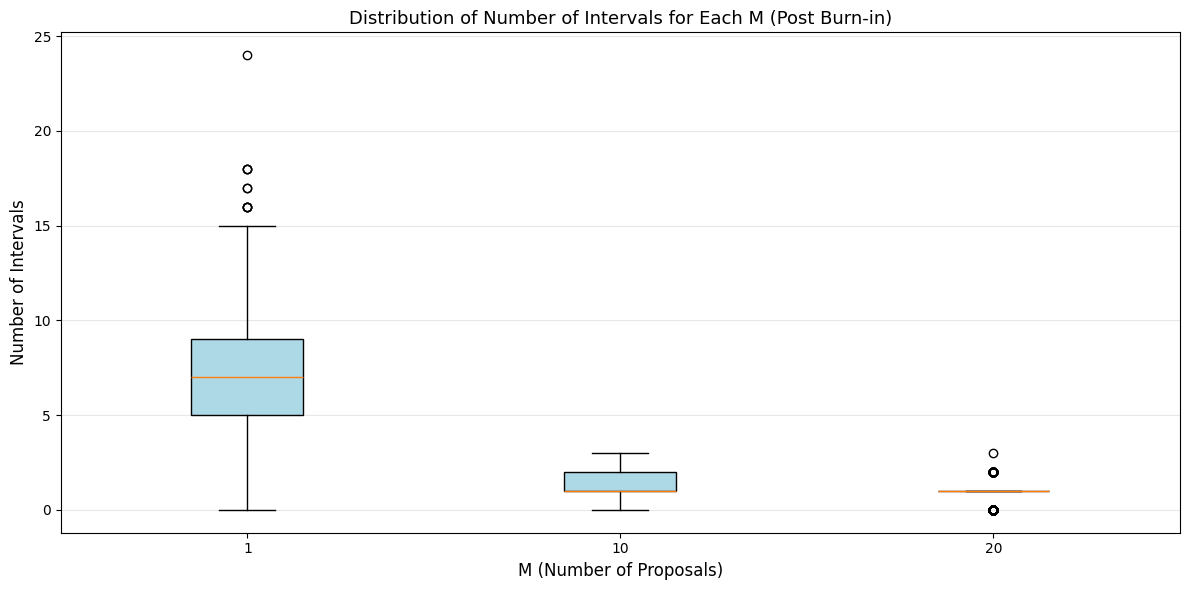


Detailed Statistics (Post Burn-in):
M          Min        Q1         Median     Q3         Max       
1          0          5          7          9          24        
10         0          1          1          2          3         
20         0          1          1          1          3         


In [9]:
fig, ax = plt.subplots(figsize=(12, 6))

# Prepare data for box plot (post burn-in only)
box_data = [results['intervals'][M][burn_in:] for M in results['M_values']]
labels = [str(M) for M in results['M_values']]

bp = ax.boxplot(box_data, labels=labels, patch_artist=True)

# Color the boxes
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')

ax.set_xlabel('M (Number of Proposals)', fontsize=12)
ax.set_ylabel('Number of Intervals', fontsize=12)
ax.set_title('Distribution of Number of Intervals for Each M (Post Burn-in)', fontsize=13)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Compute some additional statistics
print("\nDetailed Statistics (Post Burn-in):")
print("="*80)
print(f"{'M':<10} {'Min':<10} {'Q1':<10} {'Median':<10} {'Q3':<10} {'Max':<10}")
print("="*80)
for M in results['M_values']:
    intervals_post = results['intervals'][M][burn_in:]
    q1, med, q3 = np.percentile(intervals_post, [25, 50, 75])
    print(f"{M:<10} {int(np.min(intervals_post)):<10} {int(q1):<10} {int(med):<10} {int(q3):<10} {int(np.max(intervals_post)):<10}")
print("="*80)


## Run MESS with Angular Distance

Now run the same experiment with MESS using angular distance and linear programming to compute the transition matrix.


In [10]:
# Filter M_values to only use M <= 100 for angular and euclidean experiments
M_values_filtered = [M for M in M_values if M <= 100]

# Initialize results dictionaries for angular and euclidean variants
results_angular = {
    'M_values': M_values_filtered,
    'mean_intervals': [],
    'std_intervals': [],
    'median_intervals': [],
    'chains': {},
    'intervals': {},
    'times': [],
}

In [11]:
# Run experiments for each M value with angular distance
for M in M_values_filtered:
    print(f"\nRunning MESS (angular) with M = {M}...")
    
    # Initialize RNG and chain storage
    rng = np.random.default_rng(seed)
    chain = np.zeros((n_iters + 1, num_data))
    chain[0] = x0.copy()  # Initial state
    intervals = np.zeros(n_iters, dtype=int)
    x = x0.copy()
    
    # Run MCMC
    t0 = time.time()
    for t in range(n_iters):
        x, nr_intervals, _ = mess_step(x, problem, rng, M=M, use_lp=True, 
                                       distance_metric='angular', lam=0.05)
        chain[t + 1] = x
        intervals[t] = nr_intervals
    elapsed = time.time() - t0
    
    # Compute statistics (excluding burn-in)
    intervals_post_burnin = intervals[burn_in + 1:]
    mean_intervals = np.mean(intervals_post_burnin)
    std_intervals = np.std(intervals_post_burnin)
    median_intervals = np.median(intervals_post_burnin)
    
    # Store results
    results_angular['mean_intervals'].append(mean_intervals)
    results_angular['std_intervals'].append(std_intervals)
    results_angular['median_intervals'].append(median_intervals)
    results_angular['chains'][M] = chain
    results_angular['intervals'][M] = intervals
    results_angular['times'].append(elapsed)
    
    print(f"  Mean intervals: {mean_intervals:.4f} ± {std_intervals:.4f}")
    print(f"  Median intervals: {median_intervals:.1f}")
    print(f"  Time: {elapsed:.2f} seconds")

print("\n" + "="*60)
print("Experiment (Angular Distance) completed!")


Running MESS (angular) with M = 1...
  Mean intervals: 6.8799 ± 3.3613
  Median intervals: 7.0
  Time: 3.31 seconds

Running MESS (angular) with M = 10...
  Mean intervals: 1.3192 ± 0.7557
  Median intervals: 1.0
  Time: 3.50 seconds

Running MESS (angular) with M = 20...
  Mean intervals: 0.8209 ± 0.5836
  Median intervals: 1.0
  Time: 3.59 seconds

Experiment (Angular Distance) completed!


In [12]:
# Store results for MESS with euclidean distance
results_euclidean = {
    'M_values': M_values_filtered,
    'mean_intervals': [],
    'std_intervals': [],
    'median_intervals': [],
    'chains': {},
    'intervals': {},
    'times': [],
}

# Run experiments for each M value with euclidean distance
for M in M_values_filtered:
    print(f"\nRunning MESS (euclidean) with M = {M}...")
    
    # Initialize RNG and chain storage
    rng = np.random.default_rng(seed)
    chain = np.zeros((n_iters + 1, num_data))
    chain[0] = x0.copy()  # Initial state
    intervals = np.zeros(n_iters, dtype=int)
    x = x0.copy()
    
    # Run MCMC
    t0 = time.time()
    for t in range(n_iters):
        x, nr_intervals, _ = mess_step(x, problem, rng, M=M, use_lp=True, 
                                       distance_metric='euclidean', lam=0.05)
        chain[t + 1] = x
        intervals[t] = nr_intervals
    elapsed = time.time() - t0
    
    # Compute statistics (excluding burn-in)
    intervals_post_burnin = intervals[burn_in + 1:]
    mean_intervals = np.mean(intervals_post_burnin)
    std_intervals = np.std(intervals_post_burnin)
    median_intervals = np.median(intervals_post_burnin)
    
    # Store results
    results_euclidean['mean_intervals'].append(mean_intervals)
    results_euclidean['std_intervals'].append(std_intervals)
    results_euclidean['median_intervals'].append(median_intervals)
    results_euclidean['chains'][M] = chain
    results_euclidean['intervals'][M] = intervals
    results_euclidean['times'].append(elapsed)
    
    print(f"  Mean intervals: {mean_intervals:.4f} ± {std_intervals:.4f}")
    print(f"  Median intervals: {median_intervals:.1f}")
    print(f"  Time: {elapsed:.2f} seconds")

print("\n" + "="*60)
print("Experiment (Euclidean Distance) completed!")


Running MESS (euclidean) with M = 1...
  Mean intervals: 6.8799 ± 3.3613
  Median intervals: 7.0
  Time: 3.58 seconds

Running MESS (euclidean) with M = 10...
  Mean intervals: 1.3115 ± 0.8024
  Median intervals: 1.0
  Time: 3.65 seconds

Running MESS (euclidean) with M = 20...
  Mean intervals: 0.8432 ± 0.5937
  Median intervals: 1.0
  Time: 3.90 seconds

Experiment (Euclidean Distance) completed!


## Comprehensive Comparison: Three MESS Variants

Compare the number of intervals for:
1. MESS Uniform (no LP, random transition matrix)
2. MESS Angular Distance (LP + angular metric)
3. MESS Euclidean Distance (LP + euclidean metric)

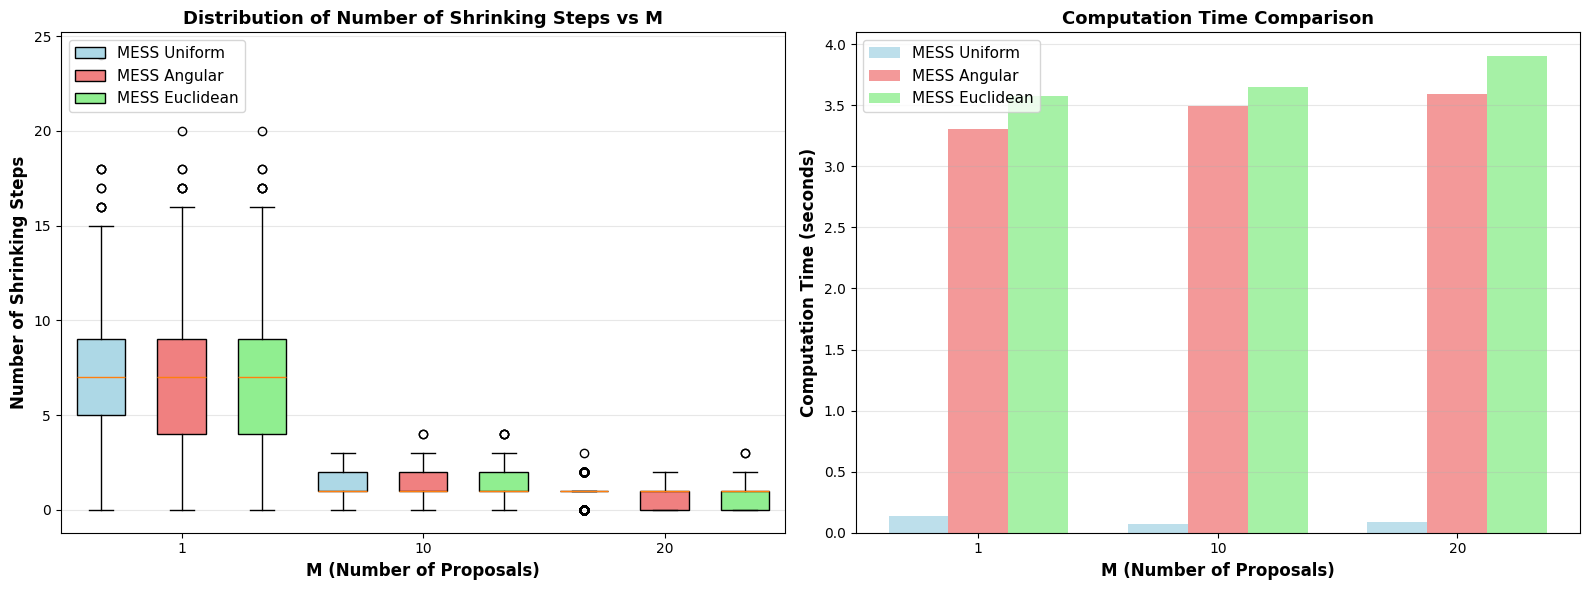


Detailed Comparison Table:
M        Method             Mean         Median       Std Dev      Min          Max          Time (s)    
1        MESS Uniform       6.9967       7.0          3.4307       0            24           0.1336      
         MESS Angular       6.8799       7.0          3.3613       0            20           3.3061      
         MESS Euclidean     6.8799       7.0          3.3613       0            20           3.5785      
--------------------------------------------------------------------------------------------------------------------------------------------
10       MESS Uniform       1.3089       1.0          0.7529       0            3            0.0753      
         MESS Angular       1.3192       1.0          0.7557       0            4            3.4954      
         MESS Euclidean     1.3115       1.0          0.8024       0            4            3.6531      
-----------------------------------------------------------------------------------------

In [ ]:
# Prepare data for the 1x2 comparison figure
# Filter uniform results to match angular/euclidean results (M <= 100 only)
idx_uniform_filtered = [i for i, M in enumerate(results['M_values']) if M <= 100]
M_compare = np.array([M for M in results['M_values'] if M <= 100])

# Create the 1x2 figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ===== LEFT PLOT: Number of Intervals Distribution =====
ax = axes[0]

# Prepare boxplot data for all three methods
uniform_box_data = [results['intervals'][M][burn_in:] for M in M_compare]
angular_box_data = [results_angular['intervals'][M][burn_in + 1:] for M in M_compare]
euclidean_box_data = [results_euclidean['intervals'][M][burn_in + 1:] for M in M_compare]

# Positions for the boxplots
num_M = len(M_compare)
positions_uniform = np.arange(num_M) * 3
positions_angular = positions_uniform + 1
positions_euclidean = positions_uniform + 2

# Create boxplots
bp1 = ax.boxplot(uniform_box_data, positions=positions_uniform, widths=0.6, 
                  patch_artist=True, label='MESS Uniform')
bp2 = ax.boxplot(angular_box_data, positions=positions_angular, widths=0.6, 
                  patch_artist=True, label='MESS Angular')
bp3 = ax.boxplot(euclidean_box_data, positions=positions_euclidean, widths=0.6, 
                  patch_artist=True, label='MESS Euclidean')

# Color the boxes
for patch in bp1['boxes']:
    patch.set_facecolor('lightblue')
for patch in bp2['boxes']:
    patch.set_facecolor('lightcoral')
for patch in bp3['boxes']:
    patch.set_facecolor('lightgreen')

# Set x-axis labels
ax.set_xticks(positions_uniform + 1)
ax.set_xticklabels([str(M) for M in M_compare])
ax.set_xlabel('M (Number of Proposals)', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Shrinking Steps', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Number of Shrinking Steps vs M', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3, axis='y')

# ===== RIGHT PLOT: Computation Time =====
ax = axes[1]

# Get times for all methods
uniform_times_filtered = np.array([results['times'][i] for i in idx_uniform_filtered])
angular_times = np.array(results_angular['times'])
euclidean_times = np.array(results_euclidean['times'])

x_pos = np.arange(num_M)
width = 0.25

ax.bar(x_pos - width, uniform_times_filtered, width, label='MESS Uniform', 
       color='lightblue', alpha=0.8)
ax.bar(x_pos, angular_times, width, label='MESS Angular', 
       color='lightcoral', alpha=0.8)
ax.bar(x_pos + width, euclidean_times, width, label='MESS Euclidean', 
       color='lightgreen', alpha=0.8)

ax.set_xticks(x_pos)
ax.set_xticklabels([str(M) for M in M_compare])
ax.set_xlabel('M (Number of Proposals)', fontsize=12, fontweight='bold')
ax.set_ylabel('Computation Time (seconds)', fontsize=12, fontweight='bold')
ax.set_title('Computation Time Comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print detailed comparison table
print("\nDetailed Comparison Table:")
print("="*140)
print(f"{'M':<8} {'Method':<18} {'Mean':<12} {'Median':<12} {'Std Dev':<12} {'Min':<12} {'Max':<12} {'Time (s)':<12}")
print("="*140)
for i, M in enumerate(M_compare):
    # Uniform
    uniform_data = results['intervals'][M][burn_in:]
    print(f"{M:<8} {'MESS Uniform':<18} {np.mean(uniform_data):<12.4f} {np.median(uniform_data):<12.1f} {np.std(uniform_data):<12.4f} {np.min(uniform_data):<12} {np.max(uniform_data):<12} {uniform_times_filtered[i]:<12.4f}")
    
    # Angular
    angular_data = results_angular['intervals'][M][burn_in + 1:]
    print(f"{'':<8} {'MESS Angular':<18} {np.mean(angular_data):<12.4f} {np.median(angular_data):<12.1f} {np.std(angular_data):<12.4f} {np.min(angular_data):<12} {np.max(angular_data):<12} {angular_times[i]:<12.4f}")
    
    # Euclidean
    euclidean_data = results_euclidean['intervals'][M][burn_in + 1:]
    print(f"{'':<8} {'MESS Euclidean':<18} {np.mean(euclidean_data):<12.4f} {np.median(euclidean_data):<12.1f} {np.std(euclidean_data):<12.4f} {np.min(euclidean_data):<12} {np.max(euclidean_data):<12} {euclidean_times[i]:<12.4f}")
    
    print("-"*140)
# print("="*140)

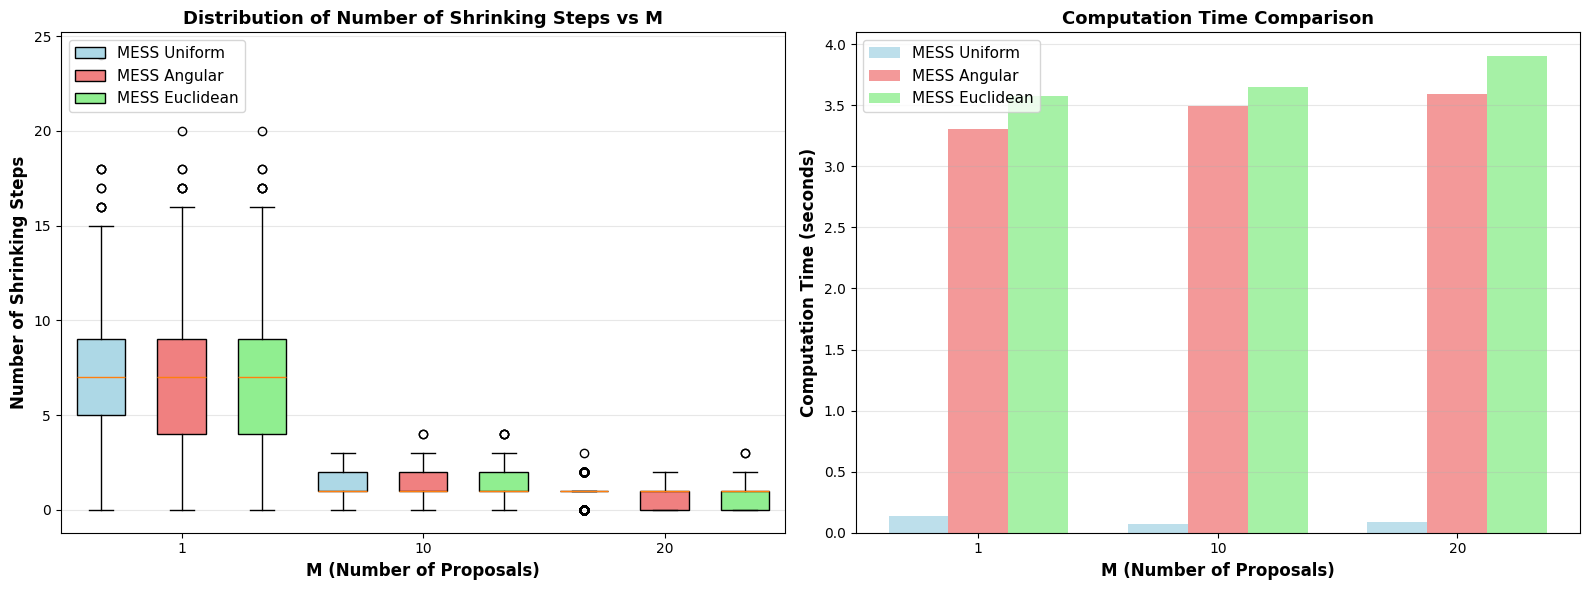


Detailed Comparison Table:
M        Method             Mean         Median       Std Dev      Min          Max          Time (s)    
1        MESS Uniform       6.9967       7.0          3.4307       0            24           0.1336      
         MESS Angular       6.8799       7.0          3.3613       0            20           3.3061      
         MESS Euclidean     6.8799       7.0          3.3613       0            20           3.5785      
--------------------------------------------------------------------------------------------------------------------------------------------
10       MESS Uniform       1.3089       1.0          0.7529       0            3            0.0753      
         MESS Angular       1.3192       1.0          0.7557       0            4            3.4954      
         MESS Euclidean     1.3115       1.0          0.8024       0            4            3.6531      
-----------------------------------------------------------------------------------------

In [ ]:
# replace this code

# Prepare data for the 1x2 comparison figure
# Filter uniform results to match angular/euclidean results (M <= 100 only)
idx_uniform_filtered = [i for i, M in enumerate(results['M_values']) if M <= 100]
M_compare = np.array([M for M in results['M_values'] if M <= 100])

# Create the 1x2 figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ===== LEFT PLOT: Number of Intervals Distribution =====
ax = axes[0]

# Prepare boxplot data for all three methods
uniform_box_data = [results['intervals'][M][burn_in:] for M in M_compare]
angular_box_data = [results_angular['intervals'][M][burn_in + 1:] for M in M_compare]
euclidean_box_data = [results_euclidean['intervals'][M][burn_in + 1:] for M in M_compare]

# Positions for the boxplots
num_M = len(M_compare)
positions_uniform = np.arange(num_M) * 3
positions_angular = positions_uniform + 1
positions_euclidean = positions_uniform + 2

# Create boxplots
bp1 = ax.boxplot(uniform_box_data, positions=positions_uniform, widths=0.6, 
                  patch_artist=True, label='MESS Uniform')
bp2 = ax.boxplot(angular_box_data, positions=positions_angular, widths=0.6, 
                  patch_artist=True, label='MESS Angular')
bp3 = ax.boxplot(euclidean_box_data, positions=positions_euclidean, widths=0.6, 
                  patch_artist=True, label='MESS Euclidean')

# Color the boxes
for patch in bp1['boxes']:
    patch.set_facecolor('lightblue')
for patch in bp2['boxes']:
    patch.set_facecolor('lightcoral')
for patch in bp3['boxes']:
    patch.set_facecolor('lightgreen')

# Set x-axis labels
ax.set_xticks(positions_uniform + 1)
ax.set_xticklabels([str(M) for M in M_compare])
ax.set_xlabel('M (Number of Proposals)', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Shrinking Steps', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Number of Shrinking Steps vs M', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3, axis='y')

# ===== RIGHT PLOT: Computation Time =====
ax = axes[1]

# Get times for all methods
uniform_times_filtered = np.array([results['times'][i] for i in idx_uniform_filtered])
angular_times = np.array(results_angular['times'])
euclidean_times = np.array(results_euclidean['times'])

x_pos = np.arange(num_M)
width = 0.25

ax.bar(x_pos - width, uniform_times_filtered, width, label='MESS Uniform', 
       color='lightblue', alpha=0.8)
ax.bar(x_pos, angular_times, width, label='MESS Angular', 
       color='lightcoral', alpha=0.8)
ax.bar(x_pos + width, euclidean_times, width, label='MESS Euclidean', 
       color='lightgreen', alpha=0.8)

ax.set_xticks(x_pos)
ax.set_xticklabels([str(M) for M in M_compare])
ax.set_xlabel('M (Number of Proposals)', fontsize=12, fontweight='bold')
ax.set_ylabel('Computation Time (seconds)', fontsize=12, fontweight='bold')
ax.set_title('Computation Time Comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print detailed comparison table
print("\nDetailed Comparison Table:")
print("="*140)
print(f"{'M':<8} {'Method':<18} {'Mean':<12} {'Median':<12} {'Std Dev':<12} {'Min':<12} {'Max':<12} {'Time (s)':<12}")
print("="*140)
for i, M in enumerate(M_compare):
    # Uniform
    uniform_data = results['intervals'][M][burn_in:]
    print(f"{M:<8} {'MESS Uniform':<18} {np.mean(uniform_data):<12.4f} {np.median(uniform_data):<12.1f} {np.std(uniform_data):<12.4f} {np.min(uniform_data):<12} {np.max(uniform_data):<12} {uniform_times_filtered[i]:<12.4f}")
    
    # Angular
    angular_data = results_angular['intervals'][M][burn_in + 1:]
    print(f"{'':<8} {'MESS Angular':<18} {np.mean(angular_data):<12.4f} {np.median(angular_data):<12.1f} {np.std(angular_data):<12.4f} {np.min(angular_data):<12} {np.max(angular_data):<12} {angular_times[i]:<12.4f}")
    
    # Euclidean
    euclidean_data = results_euclidean['intervals'][M][burn_in + 1:]
    print(f"{'':<8} {'MESS Euclidean':<18} {np.mean(euclidean_data):<12.4f} {np.median(euclidean_data):<12.1f} {np.std(euclidean_data):<12.4f} {np.min(euclidean_data):<12} {np.max(euclidean_data):<12} {euclidean_times[i]:<12.4f}")
    
    print("-"*140)
print("="*140)